# Time Series Basics

```{contents}
:local:
:depth: 2
```

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:
- Explain why time series data require special treatment compared to independently and identically distributed data.
- Load and prepare time series data with a `DatetimeIndex` in pandas, and handle missing values using forward fill, backward fill, and linear interpolation.
- Compute and interpret moving averages (`rolling().mean()`) and exponential smoothing (`ewm()`) to explore trend and seasonality.
- Define autocorrelation (ACF) and partial autocorrelation (PACF), interpret their plots, and relate them to predictability at different lag times.
- Apply the Augmented Dickey-Fuller test to assess stationarity and use first-order differencing to transform a non-stationary series into a stationary one.
:::

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('../settings/plot_style.mplstyle')

clrs = np.array(['#003057', '#EAAA00', '#4B8B9B', '#B3A369', '#377117',
                 '#1879DB', '#8E8B76', '#F5D580', '#002233'])

## What Makes Time Series Special?

Most data science methods assume observations are **independent and identically
distributed** (i.i.d.): shuffling the rows of a dataset should not affect the analysis.
Time series data violates this assumption fundamentally — measurements taken close
together in time are almost always correlated. The CO₂ concentration measured this week
is highly predictive of next week's value; the impurity level in a distillation column
at 3 PM depends on what happened at 2 PM.

Ignoring this temporal dependence has real consequences:

- A random train/test split mixes past and future, leaking information about the test
  period into the training set and producing optimistic accuracy estimates.
- Models that treat each row independently discard predictive information that is
  sitting in the lag structure.
- Standard statistical confidence intervals assume i.i.d. errors; correlated residuals
  make those intervals overconfident.

A time series can be decomposed into components that are easier to model separately:

$$x_t = T_t + S_t + C_t + \varepsilon_t$$

where $T_t$ is a **trend** (long-run increase or decrease), $S_t$ is **seasonality**
(periodic oscillations with fixed frequency), $C_t$ is **cyclicity** (irregular
long-period oscillations), and $\varepsilon_t$ is **noise**. Multiplicative
decompositions ($x_t = T_t \cdot S_t \cdot \varepsilon_t$) are also common when the
seasonal amplitude grows with the level of the series.

Understanding which components are present guides the choice of preprocessing steps
and models, as we will see throughout this chapter.

:::{exercise}
:label: ex-eda-ts-iid-split

Illustrate the danger of a random train/test split on time series data.

1. Using `dow_df['y:Impurity']`, create a random 80/20 split with
   `train_test_split(..., random_state=0)` and a chronological 80/20 split
   (first 80% of rows as training, last 20% as test).
2. For each split, fit a `LinearRegression` that uses the integer row index as the
   only feature (i.e., predict impurity from time step number). Report train and
   test $r^2$ for both splits.
3. Why does the random split produce an optimistic test $r^2$ compared to the
   chronological split?
:::

## Datasets

We will work with two complementary datasets throughout Chapters 6.1 and 6.2:

**Dow impurity (short-term, industrial):** The distillation column impurity introduced
in Module 2 and 4, measured approximately every hour over several months. It is a
short-range industrial process time series with moderate autocorrelation.

**Mauna Loa CO₂ (long-term, environmental):** Weekly atmospheric CO₂ concentration
measured at Mauna Loa, Hawaii from 1958–2002. This dataset has a strong linear trend,
clear annual seasonality, and a handful of missing values — an ideal teaching example.

### Loading the Data

In [2]:
# Dow impurity: use only the date and impurity column
df = pd.read_excel('data/impurity_dataset-training.xlsx')
dow_df = df[['Date', 'y:Impurity']].copy()
dow_df['Date'] = pd.to_datetime(dow_df['Date'])
dow_df = dow_df.set_index('Date')
print(f'Dow: {dow_df.shape},  index range: {dow_df.index.min()} → {dow_df.index.max()}')

Dow: (10703, 1),  index range: 2015-12-01 00:00:00 → 2017-02-18 23:00:00


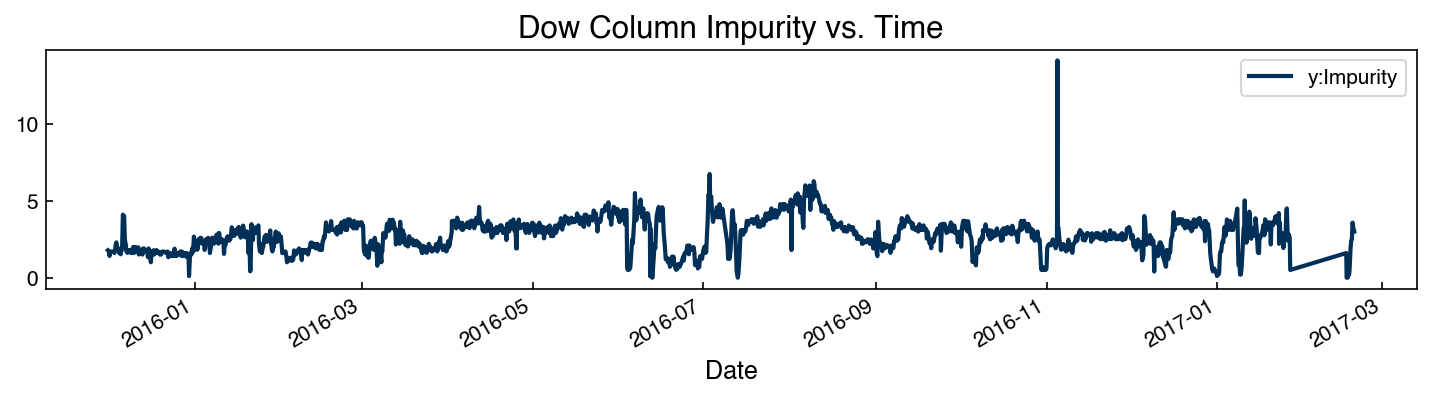

In [3]:
dow_df.plot(figsize=(10, 3))
plt.title('Dow Column Impurity vs. Time')
plt.tight_layout()

CO₂: (2284, 1),  missing: 59


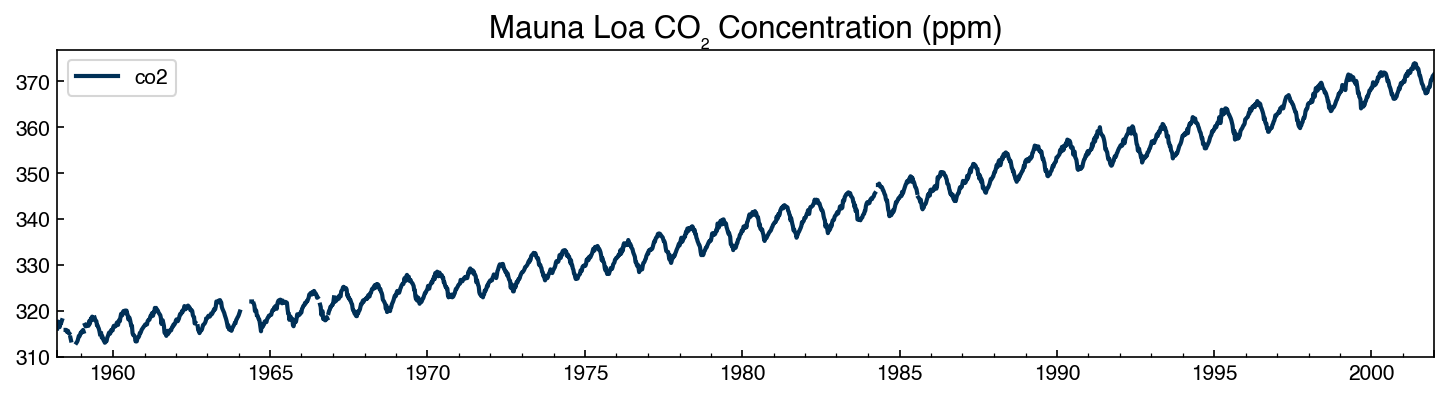

In [4]:
import statsmodels.api as sm_api

co2_raw = sm_api.datasets.co2.load_pandas().data
print(f'CO₂: {co2_raw.shape},  missing: {co2_raw["co2"].isna().sum()}')
co2_raw.plot(figsize=(10, 3))
plt.title('Mauna Loa CO₂ Concentration (ppm)')
plt.tight_layout()

You should see the CO₂ concentration rising from about 315 ppm in 1958 to 375 ppm
by 2001, with clear annual oscillations of ~7 ppm amplitude — the breathing of the
Northern Hemisphere biosphere.

:::{exercise}
:label: ex-eda-ts-dataset-explore

Explore the structure of both datasets.

1. For `dow_df`, compute the time difference between consecutive rows using
   `dow_df.index.diff()`. What is the typical sampling interval? Are there any
   gaps longer than 2 hours?
2. For `co2_raw`, report the total number of missing values and the years in which
   they occur (hint: `co2_raw[co2_raw['co2'].isna()].index.year`).
3. Plot the Dow impurity series and the CO₂ series side by side. Identify which
   of the four components (trend, seasonality, cyclicity, noise) appears to be
   present in each.
:::

---

## Data Cleaning: Missing Values and Interpolation

A single missing value in a time series can corrupt many downstream steps (differencing,
autocorrelation, ARIMA fitting all require complete series). It is therefore important
to fill gaps before analysis.

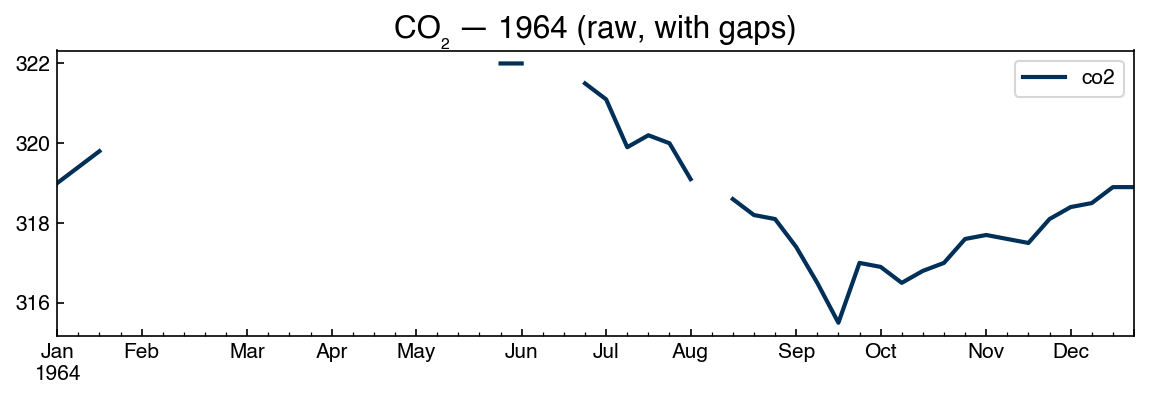

In [5]:
# Zoom in on a year with missing values
co2_raw['1964':'1964'].plot(figsize=(8, 3))
plt.title('CO₂ — 1964 (raw, with gaps)')
plt.tight_layout()

Pandas provides several strategies for filling missing values:

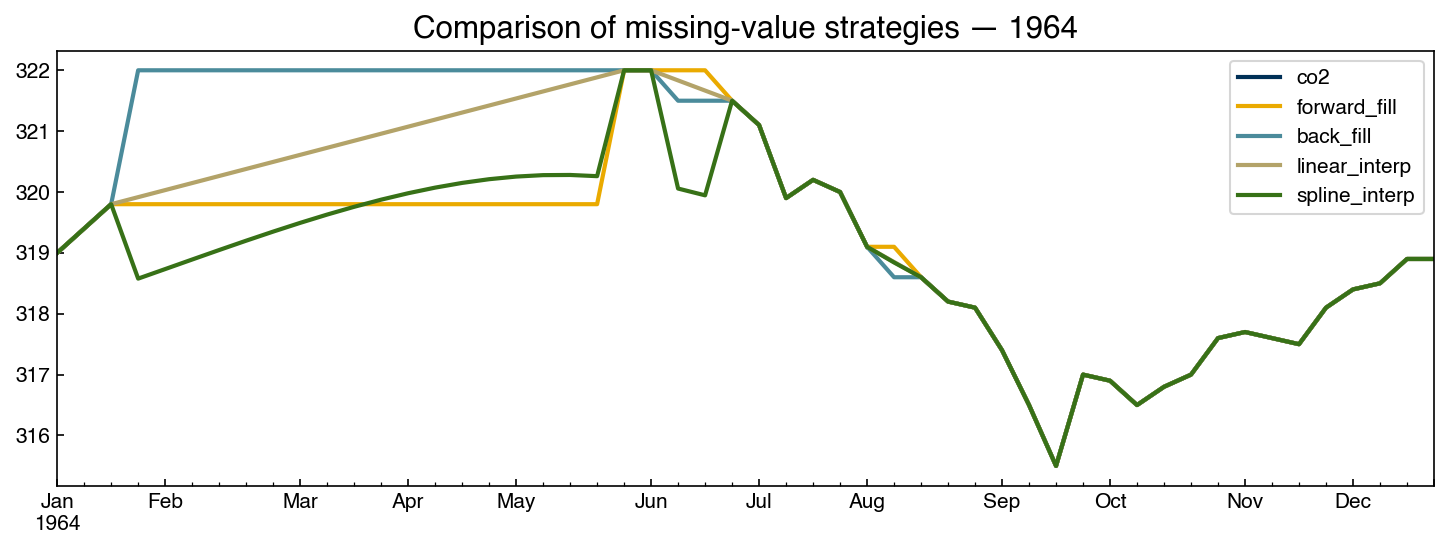

In [6]:
interp_df = co2_raw.copy()
interp_df['forward_fill']   = interp_df['co2'].ffill()
interp_df['back_fill']      = interp_df['co2'].bfill()
interp_df['linear_interp']  = interp_df['co2'].interpolate(method='linear')
interp_df['spline_interp']  = interp_df['co2'].interpolate(method='spline', order=3)

# Zoom in to compare strategies
interp_df['1964':'1964'].plot(figsize=(10, 4))
plt.title('Comparison of missing-value strategies — 1964')
plt.tight_layout()

Of these, **linear interpolation** is generally the best default for short gaps: it
avoids the staircase artifact of forward/backward fill and does not risk overfitting
to local curvature the way spline interpolation can. For gaps longer than a few
periods, consider whether the data can reasonably be predicted at all — imputation over
large gaps can introduce patterns that do not exist in the original signal.

In [7]:
# Keep interpolated series and original for comparison
co2_df = interp_df[['co2', 'linear_interp']].rename(columns={'linear_interp': 'co2_interp'})
print(f'Remaining NaNs: {co2_df["co2_interp"].isna().sum()}')
co2_df.head(5)

Remaining NaNs: 0


,co2,co2_interp
1958-03-29,316.1,316.1
1958-04-05,317.3,317.3
1958-04-12,317.6,317.6
1958-04-19,317.5,317.5
1958-04-26,316.4,316.4


:::{exercise}
:label: ex-eda-ts-interp-compare

Compare interpolation strategies on the Dow impurity series.

1. Artificially introduce 5 consecutive missing values at a location of your choice
   in `dow_df['y:Impurity']` (e.g., rows 100–104).
2. Apply forward fill, backward fill, and linear interpolation to fill the gap.
3. Plot all three filled series alongside the original (unmodified) values for the
   surrounding 20 rows. Which strategy most closely matches the original?
4. Compute the mean absolute error between each filled series and the original for
   those 5 points. Report the results.
:::

---

## Smoothing

Real signals carry high-frequency noise — sensor jitter, sampling artifacts, genuine
but short-lived fluctuations — that can obscure the slower structure (trend,
seasonality) an analysis usually targets. **Smoothing** suppresses this noise. It is
used for visualization (seeing the trend through the scatter), as preprocessing for
methods that assume a smooth underlying signal, and in online monitoring, where an
unsmoothed dashboard would flicker with every reading.

Smoothing is risky for the same reason it is useful: it removes information.
Over-smoothing can hide real, physically meaningful patterns — a short-lived process
upset, the onset of an oscillation, or the seasonal cycle itself — and every smoother
distorts the signal somewhat (a moving average, for instance, lags behind sudden
changes). Two habits help protect against this: treat the smoothing parameter as a choice that
needs justification rather than a default, and always retain and report the unsmoothed data
alongside any smoothed version, so the provenance of every figure is clear and readers
can judge for themselves what the smoothing removed.

### Moving Average

A **moving average** replaces each point with the mean of its $M$ nearest predecessors:

$$MA_t = \frac{1}{M} \sum_{j=1}^{M} x_{t-j}$$

Larger windows smooth out high-frequency noise and reveal lower-frequency trends.
Pandas implements this with `.rolling(M).mean()`:

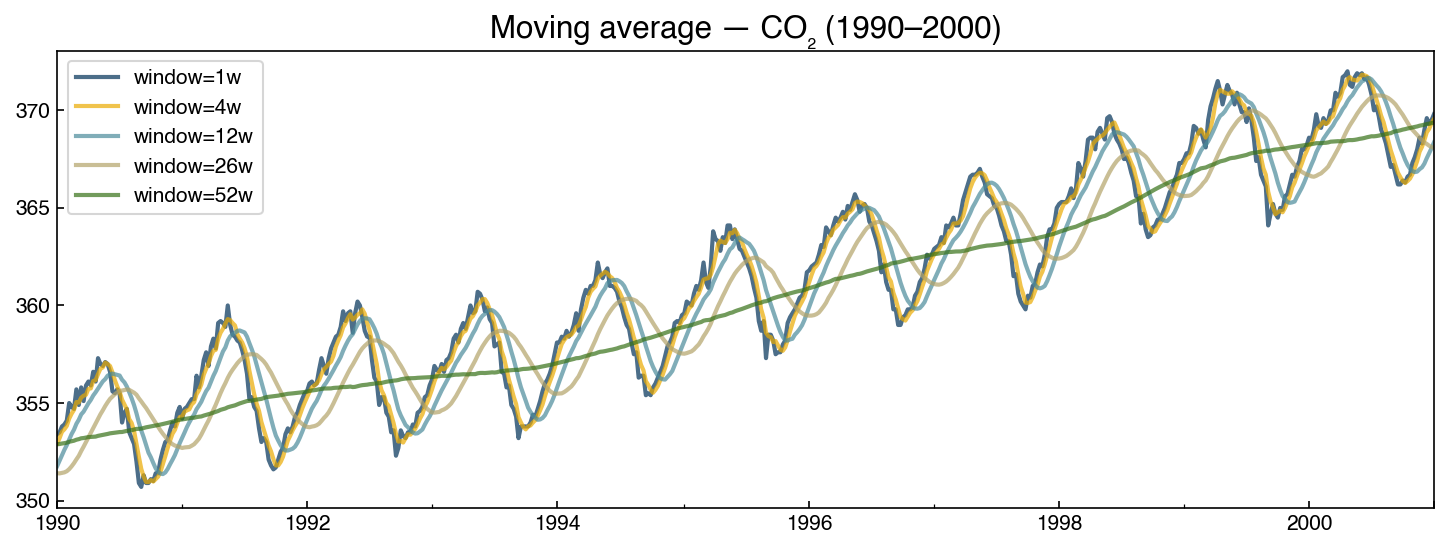

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

for window in [1, 4, 12, 26, 52]:
    ma = co2_df['co2_interp'].rolling(window).mean()
    ma['1990':'2000'].plot(ax=ax, alpha=0.7, label=f'window={window}w')

ax.legend()
ax.set_title('Moving average — CO₂ (1990–2000)')
plt.tight_layout()

At window = 52 weeks (one year), the seasonal cycle is almost entirely removed,
revealing the underlying upward trend. At smaller windows the seasonal pattern is
preserved but short-term noise is reduced.

We can also inspect the rolling standard deviation to check for **heteroscedasticity**
(variance that changes over time):

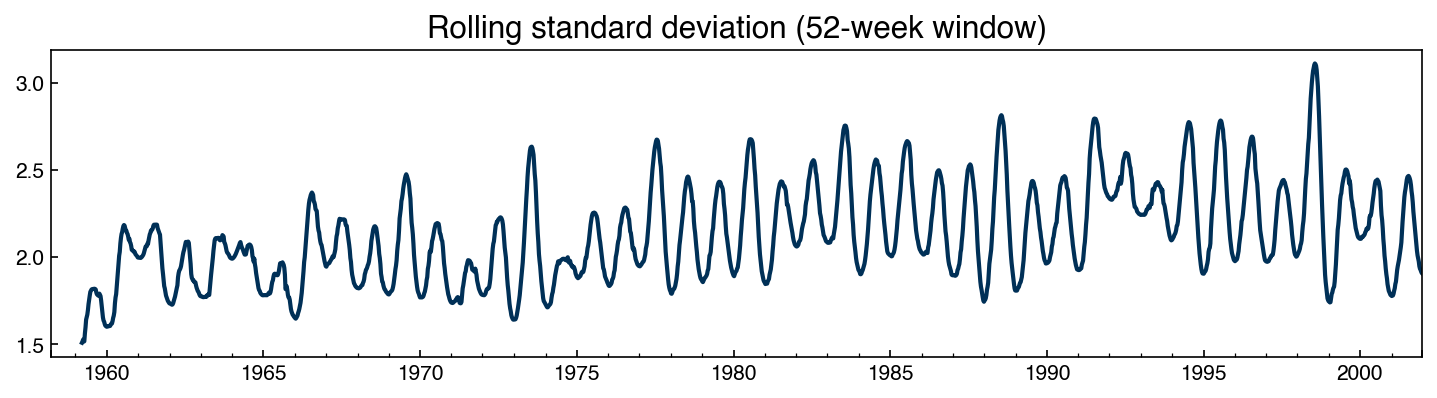

In [9]:
rolling_std = co2_df['co2_interp'].rolling(52).std()
rolling_std.plot(figsize=(10, 3))
plt.title('Rolling standard deviation (52-week window)')
plt.tight_layout()

### Exponential Smoothing

**Exponential smoothing** applies a geometrically decaying weight to past observations:

$$y_t = \alpha x_t + (1-\alpha) y_{t-1}$$

Unlike a moving average, which weights all points in the window equally, exponential
smoothing weights recent points more heavily. The parameter $\alpha \in (0,1)$ controls
the decay rate: $\alpha$ near 1 gives almost no smoothing; $\alpha$ near 0 gives strong
smoothing.

Pandas implements this with `.ewm(alpha=α).mean()`:

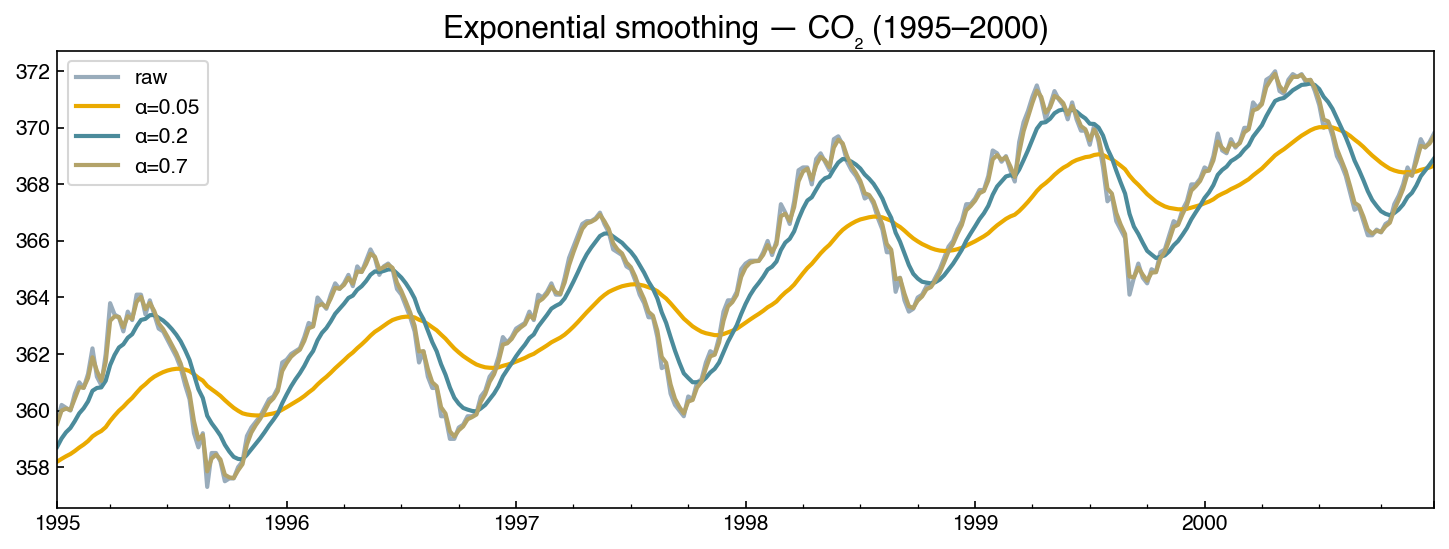

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

co2_df['co2_interp']['1995':'2000'].plot(ax=ax, label='raw', alpha=0.4)

for alpha in [0.05, 0.2, 0.7]:
    smoothed = co2_df['co2_interp'].ewm(alpha=alpha).mean()
    smoothed['1995':'2000'].plot(ax=ax, label=f'α={alpha}')

ax.legend()
ax.set_title('Exponential smoothing — CO₂ (1995–2000)')
plt.tight_layout()

### Choosing Between Them

The two smoothers suit different situations:

- A **moving average** is the right tool when the window has physical meaning. Setting
  the window equal to a known period (52 weeks here; 24 hours for a daily cycle)
  cancels that cycle exactly — which is why the 52-week window isolated the CO₂ trend
  so cleanly. It is the natural choice for retrospective analysis of a complete
  series. Its drawbacks: every point in the window counts equally, so a single outlier
  perturbs the average for a full window; the first $M-1$ points are undefined; and it
  lags sudden changes by roughly half the window length.
- **Exponential smoothing** is the right tool when recency matters or data arrive as a
  stream: it updates from a single stored value (no window buffer to maintain),
  responds faster to genuine level shifts, and has no "cliff" when a large value
  enters or leaves a finite window. This is why process dashboards and control systems
  overwhelmingly use exponential filters. Its drawbacks: the weights never reach zero,
  so no periodic component is ever removed exactly, and $\alpha$ lacks the direct
  physical interpretation that a window length has.

A reasonable default: exponential smoothing for live or streaming displays, a moving
average with a physically motivated window for analysis of historical data — and in
either case, keep the raw series in the figure.

:::{exercise}
:label: ex-eda-ts-moving-avg

Compute the moving average for the Dow impurity series with a window of 24 time steps
(approximately one day of hourly measurements).

1. Plot the raw series and the 24-step moving average on the same axes for a
   two-week period of your choice.
2. Also compute the 7-day rolling standard deviation. Does the variance appear
   to change over time (heteroscedasticity)?
3. Compare the 24-step moving average to exponential smoothing with $\alpha = 0.1$.
   Which approach removes more short-term noise? How does the choice affect the
   visibility of any day-to-day patterns?
:::

---

## Signal Compression and Data Historians

A running plant produces an enormous volume of time-series data: thousands of sensors
("tags") sampled every few seconds, continuously, for years. Storing every raw reading is
impractical, so industry relies on **data historians** — specialized time-series databases
(the AVEVA/OSIsoft *PI System* is the best known; InfluxDB is a popular open-source option)
that ingest and *compress* these streams as they arrive. The Dow dataset we are using is
itself a historian export.

Historian compression is *lossy but bounded*: it discards readings that fall within a set
tolerance of a straight line, keeping only the points needed to reconstruct the signal to
within that tolerance. The classic method is **swinging-door trending (SDT)**. Picture
standing at the last stored point and opening two "doors" — an upper slope and a lower
slope — just wide enough to keep every later point inside a corridor of half-width δ. As
each new reading arrives the doors may swing only *open*, never shut. The instant the two
doors cross — meaning no single straight line from the stored point can stay within δ of
every point seen so far — the previous point is archived and the corridor restarts there.

The geometry behind the metaphor can be made precise. Suppose the last archived point
is $(t_0, y_0)$ and readings $(t_1, y_1), \ldots, (t_k, y_k)$ have arrived since. If
all of them are eventually replaced by one straight line of slope $s$ through
$(t_0, y_0)$, reconstruction at time $t_i$ gives $y_0 + s\,(t_i - t_0)$, and the error
at that point stays within tolerance if and only if

$$\left|\, y_0 + s\,(t_i - t_0) - y_i \,\right| \le \delta
\quad\Longleftrightarrow\quad
\frac{y_i - \delta - y_0}{t_i - t_0} \;\le\; s \;\le\; \frac{y_i + \delta - y_0}{t_i - t_0}.$$

Each reading therefore admits an *interval* of acceptable slopes, and one line can
represent all $k$ readings only if those intervals overlap. The algorithm simply
tracks their running intersection: the largest lower bound seen so far (the rising
lower door — `s_max` in the code below) and the smallest upper bound (the dropping
upper door — `s_min`). Each can only move toward the other, which is why the doors
"only swing open." The moment `s_max > s_min` the intersection is empty — no line from
$(t_0, y_0)$ fits every reading within $\pm\delta$ — so the *previous* reading (the
last one for which a valid line existed) is archived and becomes the new pivot.

We can watch this happen on a toy signal. Each reading is drawn with its $\pm\delta$
tolerance band, and the shaded wedge shows every line through the pivot that passes
within $\delta$ of *all* readings so far:

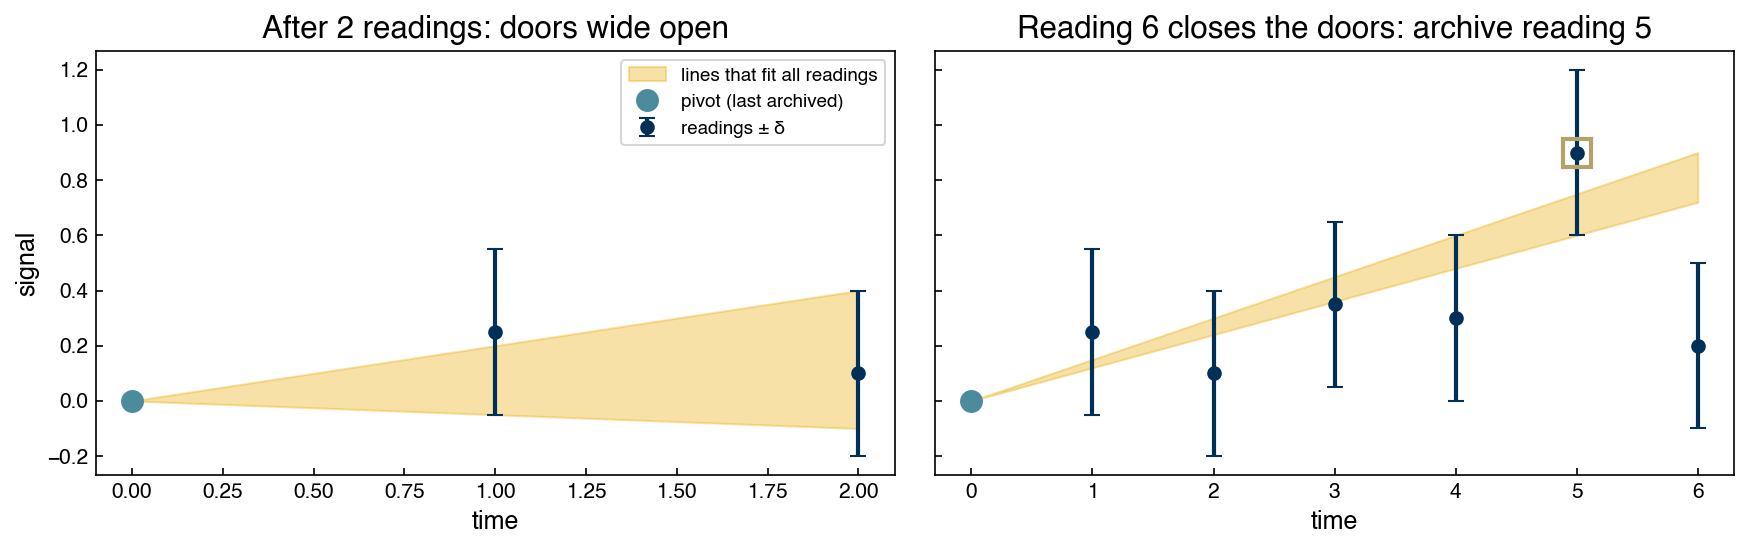

In [11]:
t_toy = np.arange(7, dtype=float)
y_toy = np.array([0.0, 0.25, 0.10, 0.35, 0.30, 0.90, 0.20])
delta_toy = 0.3

def door_slopes(k):
    """Running door slopes after seeing readings 1..k (pivot at reading 0)."""
    lo = max((y_toy[i] - delta_toy - y_toy[0]) / t_toy[i] for i in range(1, k + 1))
    hi = min((y_toy[i] + delta_toy - y_toy[0]) / t_toy[i] for i in range(1, k + 1))
    return lo, hi

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, k, title in zip(axes, [2, 6],
                        ['After 2 readings: doors wide open',
                         'Reading 6 closes the doors: archive reading 5']):
    ax.errorbar(t_toy[1:k+1], y_toy[1:k+1], yerr=delta_toy, fmt='o', capsize=4,
                color=clrs[0], label='readings ± δ')
    lo, hi = door_slopes(min(k, 5))          # wedge from the readings that still fit
    tt = np.linspace(0, t_toy[k], 50)
    ax.fill_between(tt, y_toy[0] + lo*tt, y_toy[0] + hi*tt, color=clrs[1], alpha=0.35,
                    label='lines that fit all readings')
    if k == 6:
        ax.plot(t_toy[5], y_toy[5], 's', ms=13, mfc='none', mec=clrs[3], mew=2,
                label='archived → new pivot')
    ax.plot(0, y_toy[0], 'o', ms=10, color=clrs[2], label='pivot (last archived)')
    ax.set_title(title)
    ax.set_xlabel('time')
axes[0].set_ylabel('signal')
axes[0].legend(fontsize=9)
plt.tight_layout()

In the left panel two readings still admit a wide wedge of representable lines. By
reading 5 the wedge has narrowed but survives; reading 6 (whose tolerance band sits
entirely below the wedge) makes it impossible for any single line to represent all six
readings, so the algorithm archives reading 5 and restarts the corridor from there.
Every archived point extends the stored piecewise-linear approximation by one segment,
and the guarantee $|$reconstruction $-$ signal$| \le \delta$ holds everywhere by
construction.

The full algorithm is only a few lines:

In [12]:
def swinging_door(t, y, delta):
    """Swinging-door (SDT) compression: indices of the points a historian keeps."""
    keep = [0]
    t0, y0 = t[0], y[0]
    s_max, s_min = -np.inf, np.inf          # lower-door / upper-door slopes
    for i in range(1, len(y)):
        dt = t[i] - t0
        s_min = min(s_min, (y[i] + delta - y0) / dt)
        s_max = max(s_max, (y[i] - delta - y0) / dt)
        if s_max > s_min:                   # corridor closed: archive previous point
            keep.append(i - 1)
            t0, y0 = t[i - 1], y[i - 1]
            dt = t[i] - t0
            s_min = (y[i] + delta - y0) / dt
            s_max = (y[i] - delta - y0) / dt
    keep.append(len(y) - 1)
    return np.array(sorted(set(keep)))

Compression ratio: 7.8x
Max reconstruction error: 0.0768  (tolerance δ = 0.0422)


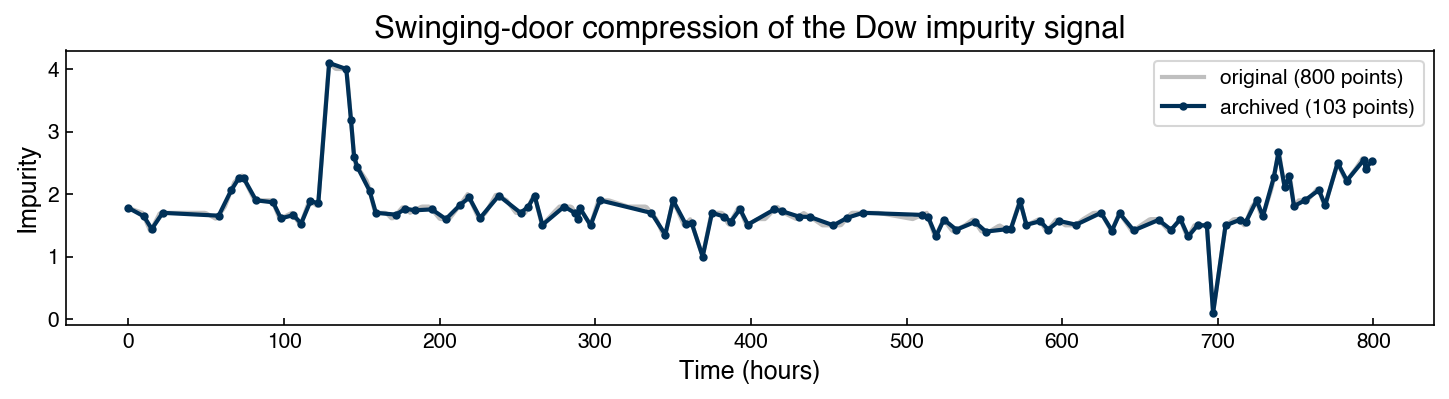

In [13]:
y = dow_df['y:Impurity'].to_numpy()[:800]
t = np.arange(len(y), dtype=float)          # hourly samples

delta = 0.1 * np.std(y)
kept = swinging_door(t, y, delta)
recon = np.interp(t, t[kept], y[kept])

plt.figure(figsize=(10, 3))
plt.plot(t, y, color='0.75', label=f'original ({len(y)} points)')
plt.plot(t[kept], y[kept], 'o-', ms=3, label=f'archived ({len(kept)} points)')
plt.xlabel('Time (hours)'); plt.ylabel('Impurity')
plt.legend(); plt.title('Swinging-door compression of the Dow impurity signal')
plt.tight_layout()

print(f'Compression ratio: {len(y) / len(kept):.1f}x')
print(f'Max reconstruction error: {np.max(np.abs(recon - y)):.4f}  (tolerance δ = {delta:.4f})')

The archived series follows the original closely while storing a fraction of the points,
and — by construction — never deviates by more than δ. At plant scale, with tens of
thousands of tags sampled every second, this is the difference between an affordable data
system and an impossible one — and it means the data you later pull from a historian *has
already been compressed*, at a resolution someone chose upstream.

:::{exercise}
:label: ex-eda-ts-historian

Investigate the compression/fidelity trade-off of the swinging-door algorithm.

1. Run `swinging_door` on the Dow impurity series for several tolerances δ (e.g.,
   0.05σ, 0.1σ, 0.25σ, 0.5σ, where σ is the standard deviation of the signal).
2. For each, record the compression ratio and the maximum reconstruction error.
3. Plot compression ratio versus δ, and describe the trade-off you observe.
:::

---

## Autocorrelation

### The Key Idea

Autocorrelation captures how correlated a time series is with a lagged version of
itself. If $x_t$ and $x_{t-k}$ are highly correlated at lag $k$, then knowing the
value at time $t-k$ helps predict the value at time $t$.

We can see this directly by plotting $x_{t-\text{lag}}$ against $x_t$:

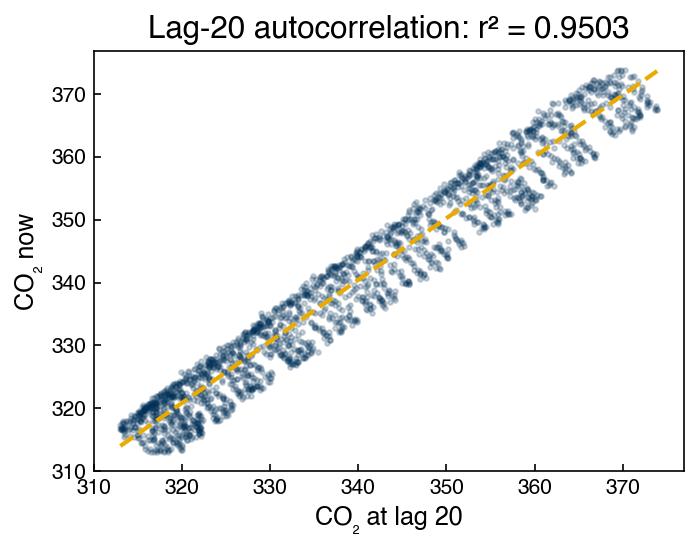

In [14]:
from scipy.stats import pearsonr

lag = 20
dataset = co2_df['co2_interp'].dropna().values

xs = dataset[:-lag]
ys = dataset[lag:]

r, _ = pearsonr(xs, ys)
r2 = r**2

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(xs, ys, alpha=0.2, s=5)
m, b = np.polyfit(xs, ys, 1)
ax.plot([xs.min(), xs.max()], [m*xs.min()+b, m*xs.max()+b], '--', color=clrs[1])
ax.set_xlabel(f'CO₂ at lag {lag}')
ax.set_ylabel('CO₂ now')
ax.set_title(f'Lag-{lag} autocorrelation: r² = {r2:.4f}')
plt.tight_layout()

The near-perfect linear relationship (slope ≈ 1) tells us that CO₂ 20 weeks ago
predicts CO₂ now with very high accuracy. This is the essence of autocorrelation.

Nothing stops us from repeating this calculation at every lag. Sweeping the lag from
1 to 100 and recording $r^2$ each time turns the single scatter plot above into a
*function of lag*:

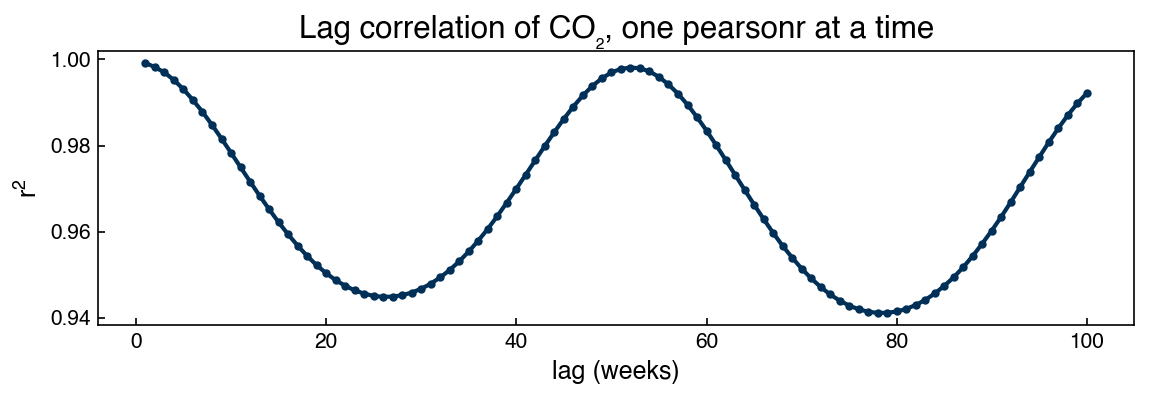

In [15]:
lags = np.arange(1, 101)
r_manual = np.array([pearsonr(dataset[:-k], dataset[k:])[0] for k in lags])

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(lags, r_manual**2, 'o-', ms=3)
ax.set_xlabel('lag (weeks)'); ax.set_ylabel('$r^2$')
ax.set_title('Lag correlation of CO₂, one pearsonr at a time')
plt.tight_layout()

The correlation is high at every lag, but it *oscillates with a one-year period*:
readings 52 weeks apart sit at the same phase of the seasonal cycle (maximum
correlation), while readings 26 weeks apart sit at opposite phases (minimum). The lag
structure of the correlation reflects the seasonality directly.

This is essentially the **autocorrelation function** that the next section formalizes.
The standard ACF differs from our loop in two small ways: it reports the signed
correlation $r$ rather than $r^2$ (so negative correlations remain visible), and it
uses the mean and variance of the *whole* series rather than recomputing them for each
pair of shifted windows:

$$\hat{\rho}_k = \frac{\sum_{t=1}^{n-k} (x_t - \bar{x})(x_{t+k} - \bar{x})}{\sum_{t=1}^{n} (x_t - \bar{x})^2}$$

Implementing that formula directly reproduces statsmodels' `acf` to machine precision:

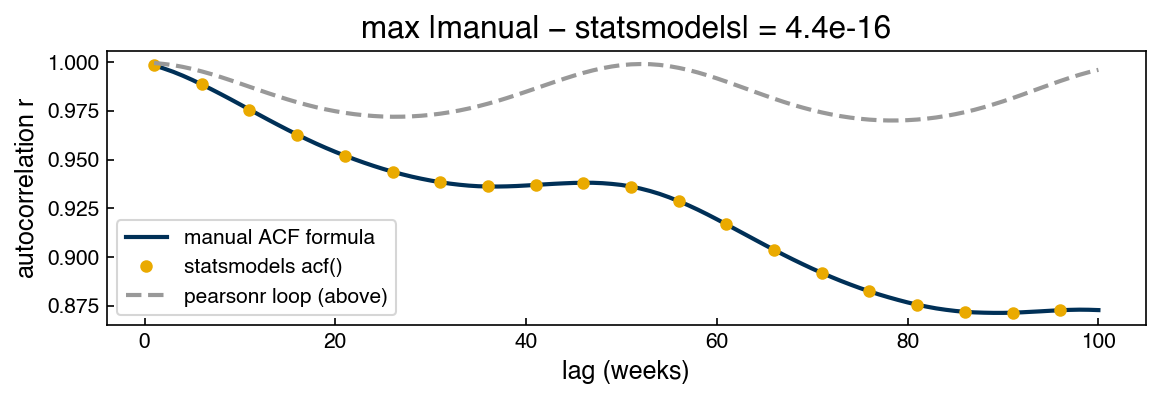

In [16]:
from statsmodels.tsa.stattools import acf

n = len(dataset)
xbar = dataset.mean()
denom = np.sum((dataset - xbar)**2)
rho_manual = np.array([np.sum((dataset[:n-k] - xbar) * (dataset[k:] - xbar)) / denom
                       for k in lags])
rho_sm = acf(dataset, nlags=100)[1:]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(lags, rho_manual, '-', label='manual ACF formula')
ax.plot(lags[::5], rho_sm[::5], 'o', ms=5, label='statsmodels acf()')
ax.plot(lags, r_manual, '--', color='0.6', label='pearsonr loop (above)')
ax.set_xlabel('lag (weeks)'); ax.set_ylabel('autocorrelation $r$')
ax.legend()
ax.set_title(f'max |manual − statsmodels| = {np.abs(rho_manual - rho_sm).max():.1e}')
plt.tight_layout()

The manual formula and statsmodels agree exactly. Notice, however, that the pearsonr
loop drifts *above* both at long lags. Using a single global mean and variance implicitly
assumes the series' statistics do not change over time — for the steadily rising CO₂
signal the shifted windows have different means, so the two estimators separate as the
lag grows. That assumption has a name — *stationarity* — and we return to it at the
end of the chapter.

### ACF and PACF Plots

The **autocorrelation function (ACF)** plots the correlation coefficient between $x_t$
and $x_{t-k}$ for each lag $k$. The **partial autocorrelation function (PACF)** shows
only the *direct* effect of lag $k$ on $x_t$, after removing the contributions of all
intermediate lags.

Conceptually: if $x_t$ is correlated with $x_{t-1}$ and $x_{t-1}$ is correlated with
$x_{t-2}$, then $x_t$ appears correlated with $x_{t-2}$ in the ACF even if there is
no direct relationship. The PACF removes this indirect correlation and shows only the
linear regression coefficient $w_k$ in:

$$x_t = \sum_{i=1}^{M} w_i x_{t-i} + \varepsilon_t$$

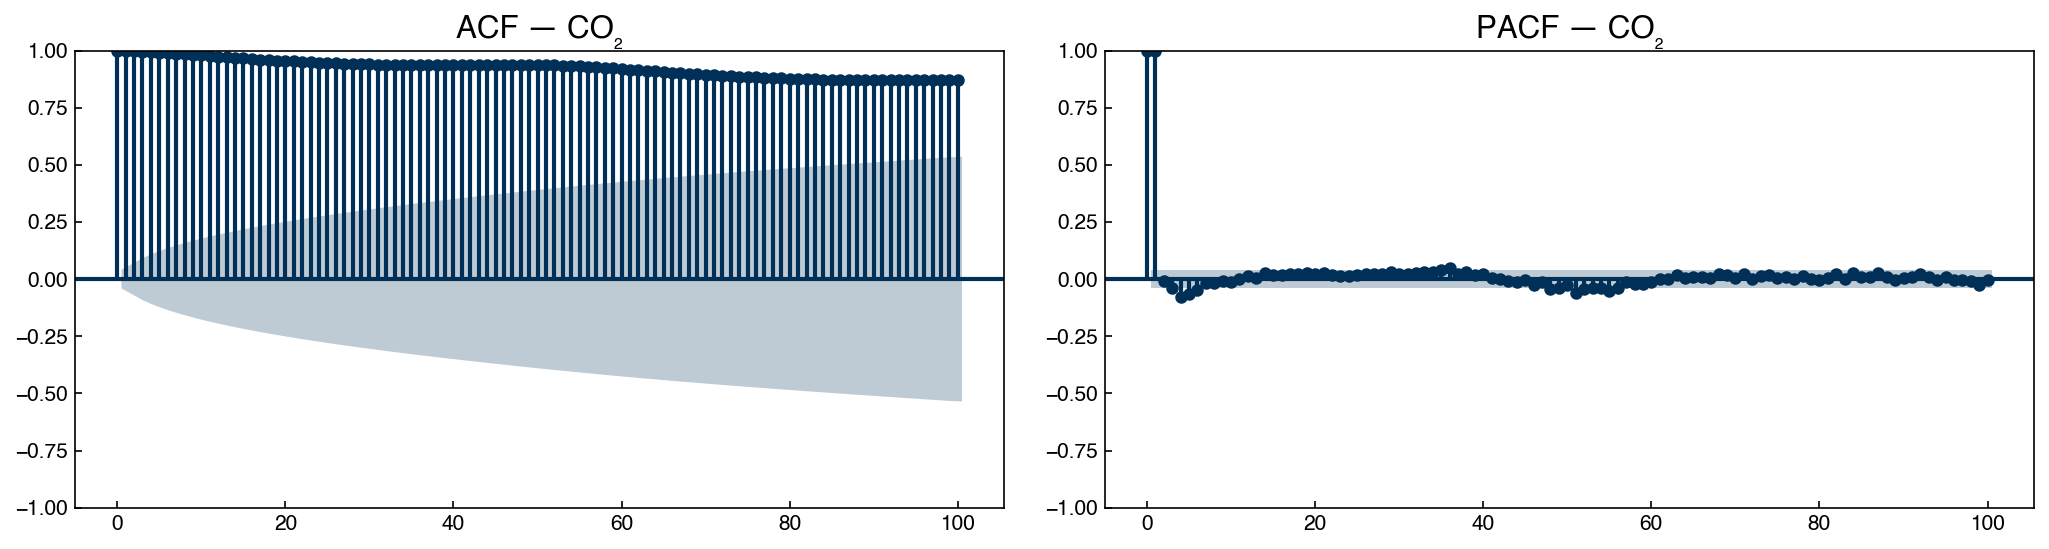

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( co2_df['co2_interp'].dropna(), lags=100, ax=axes[0], title='ACF — CO₂')
plot_pacf(co2_df['co2_interp'].dropna(), lags=100, ax=axes[1], title='PACF — CO₂')
plt.tight_layout()

The ACF for CO₂ remains very high even at 100 weeks — the series has strong long-range
dependence. The PACF decays much faster, indicating that most of the predictive
information is concentrated in the first few lags (the rest is indirect correlation).

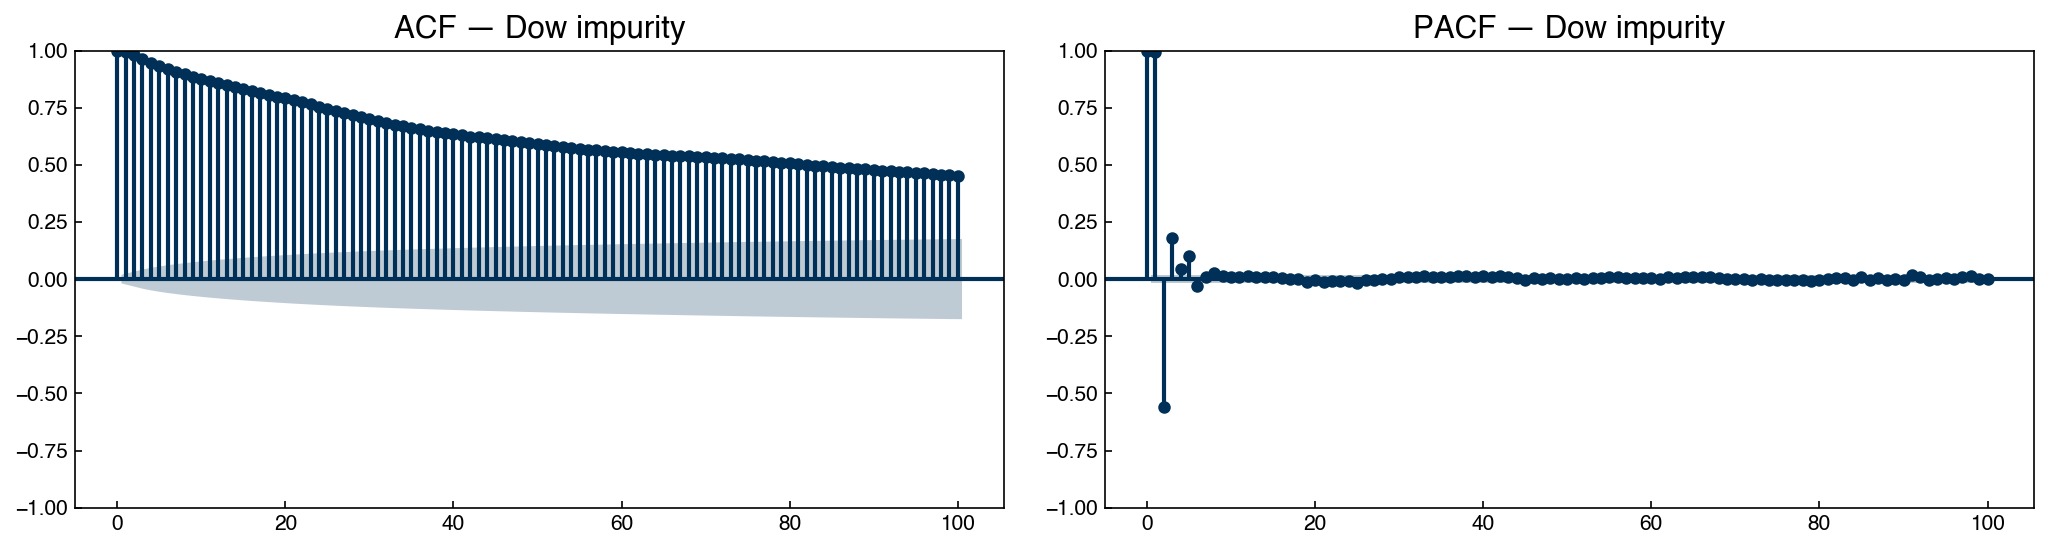

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( dow_df['y:Impurity'], lags=100, ax=axes[0], title='ACF — Dow impurity')
plot_pacf(dow_df['y:Impurity'], lags=100, ax=axes[1], title='PACF — Dow impurity')
plt.tight_layout()

The Dow impurity ACF decays more rapidly than CO₂ (shorter memory), but the PACF
still shows significant correlations out to 4–6 lags — meaning the past 4–6 time steps
contain direct predictive information.

The shaded region in each plot marks the 95% confidence band for a white-noise series.
ACF or PACF values outside this band are statistically significant.

:::{exercise}
:label: ex-eda-ts-acf-lag

Investigate the lag-correlation structure of the Dow impurity series.

1. Using `pearsonr`, compute the autocorrelation $r$ for the Dow impurity series at
   lags 1, 2, 5, 10, 24, and 48. Plot $r$ vs. lag as a bar chart.
2. At what lag does the autocorrelation first drop below 0.5?
3. Plot the ACF and PACF for the Dow impurity series (up to 50 lags). How many lags
   in the PACF are outside the 95% confidence band? What does this suggest about
   the minimum useful AR model order?
:::

---

## Stationarity

### What Stationarity Means

A time series is **stationary** if its statistical properties do not change over time:

- The mean is constant (no trend).
- The variance is constant (no heteroscedasticity).
- The autocorrelation depends only on the lag, not on when the lag is measured.

Most time series models (AR, ARIMA, spectral methods) assume stationarity. Fitting
them to non-stationary data leads to spurious correlations and unreliable forecasts.

### Augmented Dickey-Fuller Test

The **Augmented Dickey-Fuller (ADF) test** evaluates the null hypothesis that the
series has a unit root (i.e., is not stationary). A small p-value rejects the null
hypothesis and provides evidence of stationarity.

In [19]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(co2_df['co2_interp'].dropna())
p_val = adf_result[1]
print(f'ADF p-value:              {p_val:.4f}')
print(f'P(stationary) ≈ {1 - p_val:.4f}')

ADF p-value:              0.9612
P(stationary) ≈ 0.0388


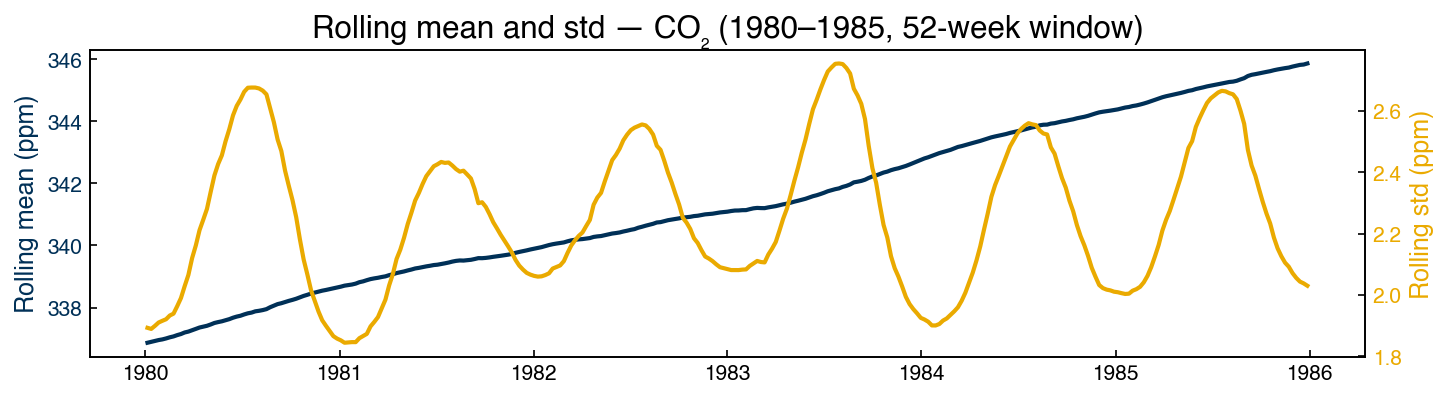

In [20]:
# Rolling statistics confirm non-stationarity visually. The mean (~340 ppm) and the
# std (~2 ppm) live on very different scales, so each gets its own y-axis.
window = 52
rolling_mean = co2_df['co2_interp'].rolling(window).mean()['1980':'1985']
rolling_std  = co2_df['co2_interp'].rolling(window).std()['1980':'1985']

fig, ax1 = plt.subplots(figsize=(10, 3))
ax1.plot(rolling_mean.index, rolling_mean, color=clrs[0])
ax1.set_ylabel('Rolling mean (ppm)', color=clrs[0])
ax1.tick_params(axis='y', labelcolor=clrs[0])

ax2 = ax1.twinx()
ax2.plot(rolling_std.index, rolling_std, color=clrs[1])
ax2.set_ylabel('Rolling std (ppm)', color=clrs[1])
ax2.tick_params(axis='y', labelcolor=clrs[1])

ax1.set_title('Rolling mean and std — CO₂ (1980–1985, 52-week window)')
plt.tight_layout()

The rising mean confirms what the ADF test found: CO₂ is not stationary. The rolling
standard deviation — readable now that it has its own axis — wiggles with the seasonal
cycle but stays near 2 ppm with no long-run trend: the non-stationarity of this series
lives in the mean, not the variance.

### First-Order Differencing

**Differencing** subtracts each value from the previous one:
$\Delta x_t = x_t - x_{t-1}$

This removes linear trends: if $x_t$ increases at a roughly constant rate, then
$\Delta x_t$ fluctuates around zero.

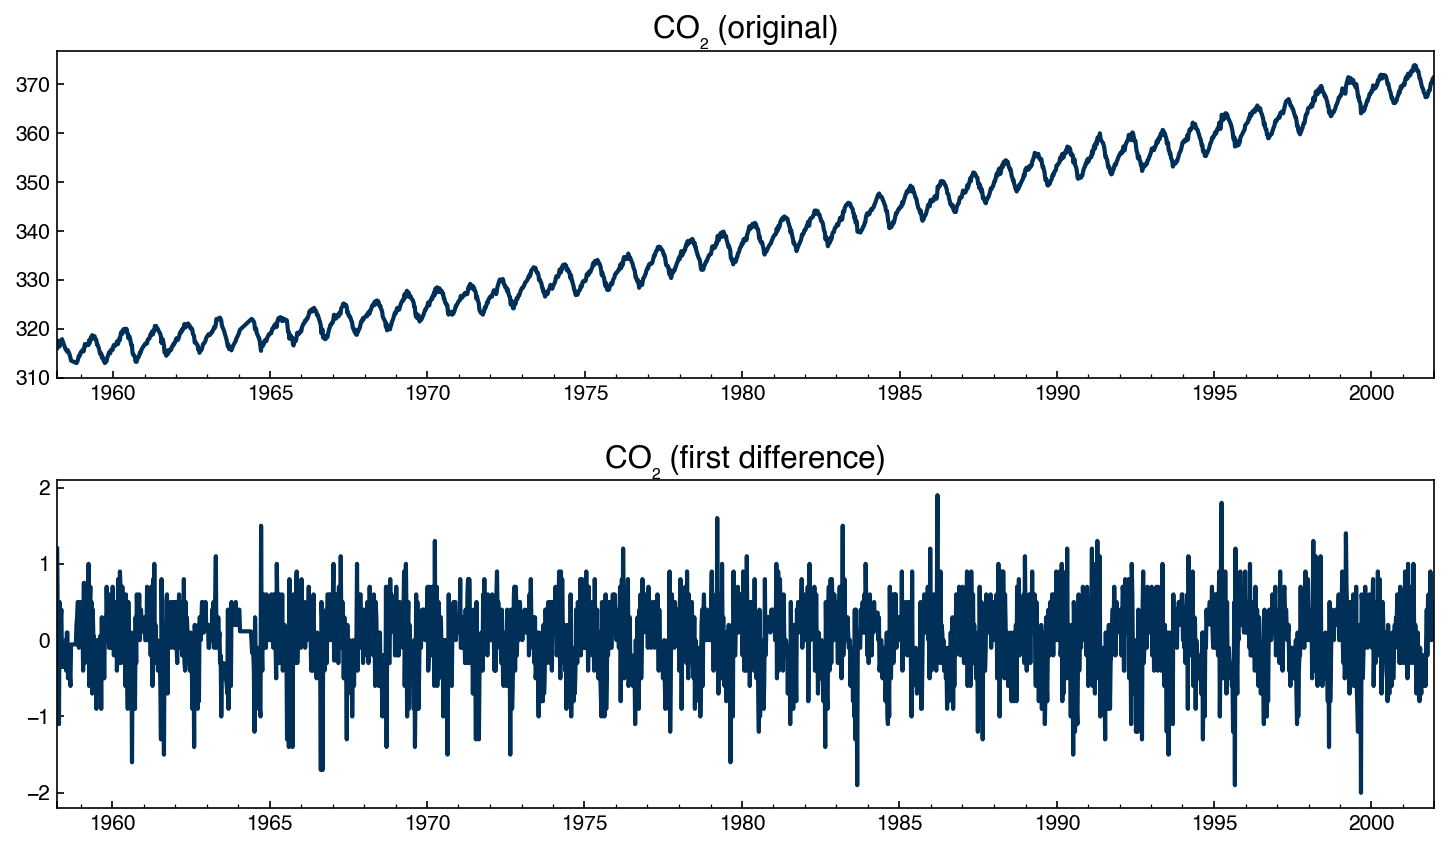

In [21]:
co2_df['co2_diff'] = co2_df['co2_interp'] - co2_df['co2_interp'].shift(1)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
co2_df['co2_interp'].plot(ax=axes[0], title='CO₂ (original)')
co2_df['co2_diff'].dropna().plot(ax=axes[1], title='CO₂ (first difference)')
plt.tight_layout()

In [22]:
# Check stationarity of the differenced series
adf_diff = adfuller(co2_df['co2_diff'].dropna())
print(f'ADF p-value after differencing: {adf_diff[1]:.4e}')
print(f'P(stationary) ≈ {1 - adf_diff[1]:.6f}')

ADF p-value after differencing: 1.3013e-28
P(stationary) ≈ 1.000000


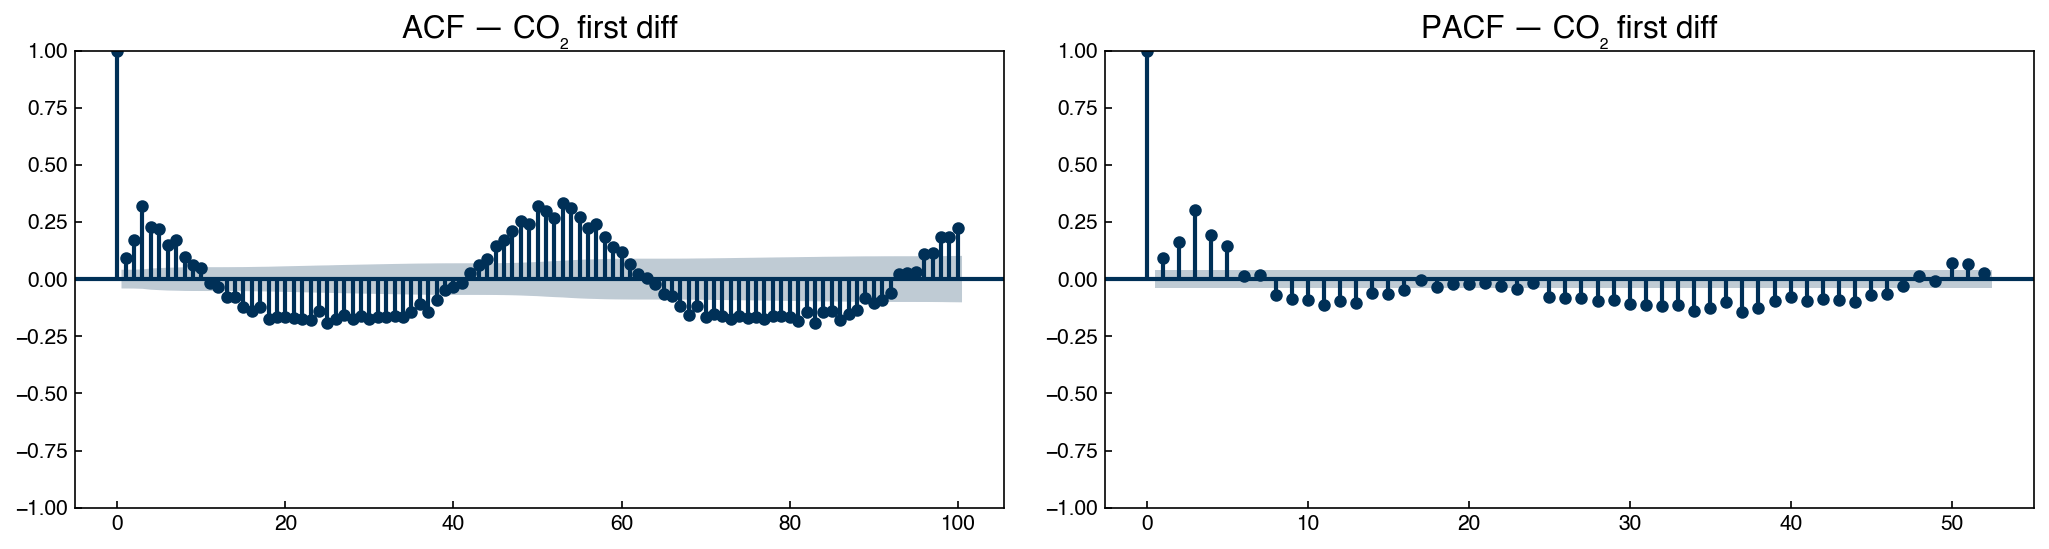

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( co2_df['co2_diff'].dropna(), lags=100, ax=axes[0], title='ACF — CO₂ first diff')
plot_pacf(co2_df['co2_diff'].dropna(), lags=52,  ax=axes[1], title='PACF — CO₂ first diff')
plt.tight_layout()

After differencing, the ACF decays rapidly and the ADF test confirms stationarity.
Notice that the seasonal pattern (annual cycle at lag ≈ 52 weeks) is now clearly
visible in the ACF — differencing removed the trend but the seasonality remains.

:::{exercise}
:label: ex-eda-ts-differencing

Apply first-order differencing to the Dow impurity series and test for stationarity.

1. Compute `dow_diff = dow_df['y:Impurity'] - dow_df['y:Impurity'].shift(1)`.
2. Run the Augmented Dickey-Fuller test on the original Dow series and on
   `dow_diff`. Report both p-values. Is the original series stationary?
3. Plot the ACF and PACF of `dow_diff` (lags = 50). How many lags are
   statistically significant in the PACF? This number ($p$) will be our
   starting point for AR model selection in Topic 6.2.
4. Compare the ACF of the Dow first difference to the ACF of the CO₂ first
   difference. What qualitative differences do you observe?
:::

---

## Summary

- Time series data are **not i.i.d.**: observations close in time are correlated,
  violating the assumptions of standard regression and classification methods. Train/test
  splits must respect chronological order.

- A time series can be decomposed into **trend** ($T$), **seasonality** ($S$),
  **cyclicity** ($C$), and **noise** ($\varepsilon$). Understanding which components
  are present guides preprocessing and model selection.

- **Missing values** in time series should be filled before analysis. Linear
  interpolation is usually the safest choice for short gaps; large gaps may need to
  be discarded.

- **Moving averages** (`rolling().mean()`) and **exponential smoothing** (`ewm()`)
  smooth out short-term fluctuations to reveal trend and seasonality. The window size
  or smoothing parameter controls the trade-off between noise reduction and signal
  preservation. Prefer a physically motivated moving-average window for retrospective
  analysis and exponential smoothing for streaming data — and always report the
  unsmoothed data alongside any smoothed version.

- **ACF** plots the total correlation between $x_t$ and $x_{t-k}$ at each lag $k$.
  **PACF** shows only the direct (partial) correlation, removing indirect effects.
  Values outside the confidence band are statistically significant.

- **Stationarity** (constant mean, variance, and autocorrelation structure) is
  required by most time series models. The **Augmented Dickey-Fuller test** quantifies
  how likely a series is to be non-stationary. **First-order differencing** removes
  linear trends and often achieves stationarity.

## Additional Reading

- Hyndman, R. J. & Athanasopoulos, G. (2021), *Forecasting: Principles and Practice*
  (3rd ed.) — comprehensive open-access textbook at [otexts.com/fpp3](https://otexts.com/fpp3/)
- Brockwell, P. J. & Davis, R. A. (2016), *Introduction to Time Series and Forecasting*
  (3rd ed.) — rigorous treatment of ARIMA and spectral methods
- pandas documentation:
  [Time Series / Date functionality](https://pandas.pydata.org/docs/user_guide/timeseries.html),
  [Window functions](https://pandas.pydata.org/docs/user_guide/window.html)
- statsmodels:
  [tsa module](https://www.statsmodels.org/stable/tsa.html)